# Model C — Fine-tuned LLM, không RAG

Notebook này chỉ thực hiện **Model C** trong đề tài:

- Base model: `meta-llama/Llama-3.2-3B`
- Dữ liệu train: `data_no_RAG.json` gồm các cặp `Q/A`
- Fine-tuning: LoRA/QLoRA bằng PEFT
- Đánh giá: `human_eval_50.json` với BLEU, ROUGE-1/2/L, BERTScore-F1
- Output: LoRA adapter + tokenizer + file kết quả đánh giá trên Google Drive


## 0. Cài đặt thư viện

Chạy cell này trước. Nếu Colab yêu cầu restart runtime sau khi cài, restart rồi chạy lại từ cell import.


In [1]:
!pip install -q -U transformers accelerate peft datasets bitsandbytes evaluate rouge_score bert_score sentencepiece matplotlib "protobuf<6"


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.3 MB/s eta 0:00:00


## 1. Imports, Drive và GPU

In [1]:
import gc
import inspect
import json
import os
import re
import shutil
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

try:
    from google.colab import drive, userdata
    IN_COLAB = True
    drive.mount('/content/drive')
except Exception:
    IN_COLAB = False
    userdata = None

assert torch.cuda.is_available(), 'Bật GPU trong Colab: Runtime -> Change runtime type -> T4/A100.'
GPU_MAJOR, GPU_MINOR = torch.cuda.get_device_capability(0)
USE_BF16 = GPU_MAJOR >= 8
print('GPU:', torch.cuda.get_device_name(0))
print('Capability:', f'{GPU_MAJOR}.{GPU_MINOR}')
print('Precision:', 'bf16' if USE_BF16 else 'fp16')


Mounted at /content/drive
GPU: Tesla T4
Capability: 7.5
Precision: fp16


## 2. Cấu hình

Nếu chạy trên Colab, đặt 2 file JSON vào `/content/drive/MyDrive/` hoặc chỉnh `DATA_DIR` bên dưới.

Token Hugging Face nên để trong Colab Secrets với tên `HF_TOKEN`, hoặc nhập khi notebook hỏi.


In [ ]:
def get_hf_token():
    token = os.environ.get('HF_TOKEN')
    if token:
        return token
    if userdata is not None:
        try:
            token = userdata.get('HF_TOKEN')
            if token:
                return token
        except Exception:
            pass
    return input('Nhập HF_TOKEN: ').strip()

HF_TOKEN = get_hf_token()
BASE_MODEL = 'meta-llama/Llama-3.2-3B'

DATA_DIR = Path('/content/drive/MyDrive') if IN_COLAB else Path('.')
TRAIN_PATH = DATA_DIR / 'data_no_RAG.json'
EVAL_PATH = DATA_DIR / 'human_eval_50.json'

DRIVE_BASE = DATA_DIR / 'models'
DIR_C = DRIVE_BASE / 'model_C_no_rag'
RESULT_PATH = DRIVE_BASE / 'model_C_eval.json'
TRAIN_LOG_PATH = DRIVE_BASE / 'model_C_train_log.json'
CURVE_PLOT_PATH = DRIVE_BASE / 'model_C_training_curve.png'
METRIC_PLOT_PATH = DRIVE_BASE / 'model_C_metric_plot.png'

MAX_LENGTH = 1024
MAX_NEW_TOKENS = 256
SEED = 42
EPOCHS = 10
BATCH_SIZE = 2
GRAD_ACC = 8
LR = 2e-4
USE_4BIT = True
TRAIN_ON_ALL_DATA = True
FORCE_RETRAIN = True
SKIP_IF_EXISTS = False

print('Train file:', TRAIN_PATH)
print('Eval file :', EVAL_PATH)
print('Save dir  :', DIR_C)


## 3. Load dữ liệu

In [4]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

train_data = load_json(TRAIN_PATH)
human_eval = load_json(EVAL_PATH)

print(f'Train samples: {len(train_data)}')
print(f'Human eval   : {len(human_eval)}')
print('Sample train:', train_data[0])
print('Sample eval :', human_eval[0])


Train samples: 350
Human eval   : 50
Sample train: {'Q': 'Luật Trật tự, an toàn giao thông đường bộ có hiệu lực thi hành từ ngày nào?', 'A': 'Ngày 01 tháng 01 năm 2025'}
Sample eval : {'Q': 'Luật Trật tự, an toàn giao thông đường bộ 2024 do cơ quan nào ban hành?', 'A': 'Quốc hội.'}


## 4. Tokenizer và prompt không RAG

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, token=HF_TOKEN, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'


def extract_question(raw_q: str) -> str:
    q = str(raw_q or '').strip()
    for prefix in ['Câu hỏi:\n', '### Câu hỏi:\n', 'Câu hỏi:', '### Câu hỏi:']:
        if q.startswith(prefix):
            q = q[len(prefix):].strip()
            break
    q = re.sub(r'\n*#+\s*Trả lời:\s*$', '', q).strip()
    return q


def build_prompt_no_rag(question: str) -> str:
    question = extract_question(question)
    return (
        '### Hướng dẫn:\n'
        'Trả lời ngắn gọn, chính xác câu hỏi về luật giao thông đường bộ Việt Nam.\n\n'
        f'### Câu hỏi:\n{question}\n\n'
        '### Trả lời:\n'
    )

print(build_prompt_no_rag(train_data[0]['Q']))


config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

### Hướng dẫn:
Trả lời ngắn gọn, chính xác câu hỏi về luật giao thông đường bộ Việt Nam.

### Câu hỏi:
Luật Trật tự, an toàn giao thông đường bộ có hiệu lực thi hành từ ngày nào?

### Trả lời:



## 5. Tạo dataset train/validation/test

In [6]:
from datasets import Dataset


def tokenize_example(example):
    full_text = example['prompt'] + example['answer'] + tokenizer.eos_token
    tokenized = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
        add_special_tokens=False,
    )
    prompt_len = len(
        tokenizer(
            example['prompt'],
            truncation=True,
            max_length=MAX_LENGTH,
            padding=False,
            add_special_tokens=False,
        )['input_ids']
    )
    labels = tokenized['input_ids'].copy()
    labels[:prompt_len] = [-100] * prompt_len
    tokenized['labels'] = labels
    return tokenized

records = [
    {'prompt': build_prompt_no_rag(item['Q']), 'answer': str(item['A']).strip()}
    for item in train_data
    if item.get('Q') and item.get('A')
]

dataset = Dataset.from_list(records).map(
    tokenize_example,
    remove_columns=['prompt', 'answer'],
    desc='Tokenizing Model C data',
)

split_1 = dataset.train_test_split(test_size=0.20, seed=SEED)
split_2 = split_1['test'].train_test_split(test_size=0.50, seed=SEED)

ds_train = dataset if TRAIN_ON_ALL_DATA else split_1['train']
ds_val = split_2['train']
ds_test = split_2['test']

print(f'Train={len(ds_train)} | Val={len(ds_val)} | Test={len(ds_test)}')
if TRAIN_ON_ALL_DATA:
    print('Đang train trên toàn bộ 350 mẫu; human_eval_50.json là tập test chính.')


Tokenizing Model C data:   0%|          | 0/350 [00:00<?, ? examples/s]

Train=350 | Val=35 | Test=35
Đang train trên toàn bộ 350 mẫu; human_eval_50.json là tập test chính.


## 6. Train Model C bằng LoRA/QLoRA

In [7]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig, DataCollatorForSeq2Seq, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel


def make_training_args():
    params = inspect.signature(TrainingArguments.__init__).parameters
    kwargs = dict(
        output_dir='model_C_no_rag_ckpt',
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACC,
        learning_rate=LR,
        warmup_steps=10,
        lr_scheduler_type='cosine',
        logging_steps=10,
        save_strategy='epoch',
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        fp16=not USE_BF16,
        bf16=USE_BF16,
        report_to='none',
        remove_unused_columns=False,
        seed=SEED,
        optim='paged_adamw_8bit' if USE_4BIT else 'adamw_torch',
    )
    kwargs['eval_strategy' if 'eval_strategy' in params else 'evaluation_strategy'] = 'epoch'
    return TrainingArguments(**kwargs)

model_exists = (DIR_C / 'adapter_config.json').exists()

if FORCE_RETRAIN and model_exists:
    print(f'Xóa adapter cũ để train lại sạch: {DIR_C}')
    shutil.rmtree(DIR_C)
    model_exists = False

if SKIP_IF_EXISTS and model_exists:
    print(f'Model C đã tồn tại tại {DIR_C}. Bỏ qua training.')
else:
    gc.collect()
    torch.cuda.empty_cache()

    quant_config = None
    model_kwargs = dict(
        token=HF_TOKEN,
        device_map='auto',
        low_cpu_mem_usage=True,
    )
    if USE_4BIT:
        quant_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_compute_dtype=torch.bfloat16 if USE_BF16 else torch.float16,
        )
        model_kwargs['quantization_config'] = quant_config
    else:
        model_kwargs['torch_dtype'] = torch.bfloat16 if USE_BF16 else torch.float16

    model_C = AutoModelForCausalLM.from_pretrained(BASE_MODEL, **model_kwargs)
    model_C.config.use_cache = False

    if USE_4BIT:
        model_C = prepare_model_for_kbit_training(model_C)
    if hasattr(model_C, 'enable_input_require_grads'):
        model_C.enable_input_require_grads()

    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
        lora_dropout=0.0,
        bias='none',
        task_type='CAUSAL_LM',
    )
    model_C = get_peft_model(model_C, lora_config)
    model_C.print_trainable_parameters()

    trainer_kwargs = dict(
        model=model_C,
        args=make_training_args(),
        train_dataset=ds_train,
        eval_dataset=ds_val,
        data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True, return_tensors='pt'),
    )
    if 'processing_class' in inspect.signature(Trainer.__init__).parameters:
        trainer_kwargs['processing_class'] = tokenizer
    else:
        trainer_kwargs['tokenizer'] = tokenizer

    trainer = Trainer(**trainer_kwargs)
    train_result = trainer.train()
    train_logs = trainer.state.log_history

    DIR_C.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(DIR_C))
    tokenizer.save_pretrained(str(DIR_C))

    TRAIN_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(TRAIN_LOG_PATH, 'w', encoding='utf-8') as f:
        json.dump(train_logs, f, ensure_ascii=False, indent=2)

    print(f'Saved Model C LoRA adapter to: {DIR_C}')
    print(f'Saved training log to: {TRAIN_LOG_PATH}')

    del trainer, model_C
    gc.collect()
    torch.cuda.empty_cache()


Xóa adapter cũ để train lại sạch: /content/drive/MyDrive/models/model_C_no_rag


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

...

trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,1.555241,1.133617
2,1.089778,0.640687
3,0.669283,0.343003
4,0.325133,0.143689
5,0.173388,0.077087
6,0.089133,0.047159
7,0.044918,0.029889
8,0.026497,0.016065
9,0.013550,0.010867
10,0.011238,0.010532


/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1419: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-69f9d800-3ad01094113dc35b7aef04cd;b7db11d7-4fe7-43be-9b9e-8c150a60c881)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.2-3B/resolve/main/config.json.
Access to model meta-llama/Llama-3.2-3B is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.2-3B.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:372: UserWarning: Could not find a config file in meta-llama/Llama-3.2-3B - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling chec

Saved Model C LoRA adapter to: /content/drive/MyDrive/models/model_C_no_rag
Saved training log to: /content/drive/MyDrive/models/model_C_train_log.json


## 7. Plot training curve

Cell này vẽ lại đường cong `train loss` và `eval loss` từ log vừa train. Ảnh được lưu vào Google Drive để đưa vào báo cáo/slide.


Train log points: 22 | Eval log points: 10


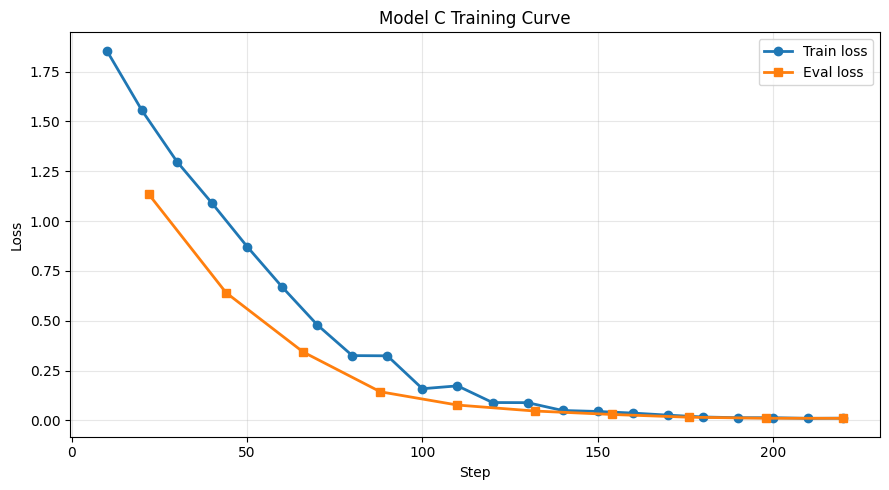

Saved curve plot to: /content/drive/MyDrive/models/model_C_training_curve.png


In [8]:
def load_train_logs():
    if 'train_logs' in globals() and train_logs:
        return train_logs
    if TRAIN_LOG_PATH.exists():
        with open(TRAIN_LOG_PATH, 'r', encoding='utf-8') as f:
            return json.load(f)

    ckpt_root = Path('model_C_no_rag_ckpt')
    state_files = sorted(ckpt_root.glob('checkpoint-*/trainer_state.json'))
    if state_files:
        def step_of(path):
            m = re.search(r'checkpoint-(\d+)', str(path))
            return int(m.group(1)) if m else -1
        best_state = sorted(state_files, key=step_of)[-1]
        with open(best_state, 'r', encoding='utf-8') as f:
            return json.load(f).get('log_history', [])
    return []

logs_for_plot = load_train_logs()
train_points = [(x.get('step'), x.get('loss')) for x in logs_for_plot if x.get('loss') is not None]
eval_points = [(x.get('step'), x.get('eval_loss')) for x in logs_for_plot if x.get('eval_loss') is not None]

print(f'Train log points: {len(train_points)} | Eval log points: {len(eval_points)}')

if not train_points and not eval_points:
    print('Chưa có training log để plot. Hãy chạy lại cell train, hoặc giữ checkpoint model_C_no_rag_ckpt trong runtime.')
else:
    plt.figure(figsize=(9, 5))
    if train_points:
        steps, losses = zip(*train_points)
        plt.plot(steps, losses, marker='o', linewidth=2, label='Train loss')
    if eval_points:
        steps, losses = zip(*eval_points)
        plt.plot(steps, losses, marker='s', linewidth=2, label='Eval loss')
    plt.title('Model C Training Curve')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    CURVE_PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(CURVE_PLOT_PATH, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved curve plot to:', CURVE_PLOT_PATH)


## 8. Load Model C để inference

In [9]:
def load_model_C():
    model_kwargs = dict(
        token=HF_TOKEN,
        device_map='auto',
        low_cpu_mem_usage=True,
    )
    if USE_4BIT:
        model_kwargs['quantization_config'] = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_compute_dtype=torch.bfloat16 if USE_BF16 else torch.float16,
        )
    else:
        model_kwargs['torch_dtype'] = torch.bfloat16 if USE_BF16 else torch.float16

    base = AutoModelForCausalLM.from_pretrained(BASE_MODEL, **model_kwargs)
    model = PeftModel.from_pretrained(base, str(DIR_C)).eval()
    return model

model_C = load_model_C()
print('Model C loaded.')


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Model C loaded.


## 9. Sinh câu trả lời

In [10]:
def post_process(text: str) -> str:
    text = str(text or '').strip()
    for stop in ['### Câu hỏi:', '### Hướng dẫn:', '### Ngữ cảnh:', '### Trả lời:', '\nQ:', '\nA:']:
        idx = text.find(stop)
        if idx != -1:
            text = text[:idx].strip()
    text = text.split('\n\n', 1)[0].strip()
    text = re.sub(r'\s+', ' ', text)
    if text.endswith(';'):
        text = text[:-1] + '.'
    return text.strip()


def generate_model_C(question: str) -> str:
    prompt = build_prompt_no_rag(question)
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=MAX_LENGTH).to(model_C.device)
    with torch.no_grad():
        output = model_C.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            repetition_penalty=1.15,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    generated = output[0][inputs['input_ids'].shape[1]:]
    return post_process(tokenizer.decode(generated, skip_special_tokens=True, clean_up_tokenization_spaces=False))

sanity_q = train_data[0]['Q']
sanity_gold = train_data[0]['A']
sanity_pred = generate_model_C(sanity_q)
print('Sanity Q   :', sanity_q)
print('Sanity Gold:', sanity_gold)
print('Sanity Pred:', sanity_pred)


Sanity Q   : Luật Trật tự, an toàn giao thông đường bộ có hiệu lực thi hành từ ngày nào?
Sanity Gold: Ngày 01 tháng 01 năm 2025
Sanity Pred: Ngày 01 tháng 01 năm 2025


## 10. Đánh giá trên 50 câu human eval

In [11]:
import evaluate as hf_evaluate

bleu_metric = hf_evaluate.load('bleu')
rouge_metric = hf_evaluate.load('rouge')
bert_metric = hf_evaluate.load('bertscore')


def compute_metrics(preds, refs):
    safe_preds = [pred if pred.strip() else '.' for pred in preds]
    bleu = bleu_metric.compute(predictions=safe_preds, references=[[ref] for ref in refs])['bleu']
    rouge = rouge_metric.compute(predictions=safe_preds, references=refs)
    bert = bert_metric.compute(predictions=safe_preds, references=refs, lang='vi')
    return {
        'BLEU': round(float(bleu), 4),
        'ROUGE-1': round(float(rouge['rouge1']), 4),
        'ROUGE-2': round(float(rouge['rouge2']), 4),
        'ROUGE-L': round(float(rouge['rougeL']), 4),
        'BERT-F1': round(float(np.mean(bert['f1'])), 4),
    }

preds, refs, rows = [], [], []
for i, item in enumerate(human_eval, start=1):
    pred = generate_model_C(item['Q'])
    gold = str(item['A']).strip()
    preds.append(pred)
    refs.append(gold)
    rows.append({'Q': item['Q'], 'gold': gold, 'pred': pred})
    if i % 10 == 0 or i == len(human_eval):
        print(f'{i}/{len(human_eval)}')

metrics_C = compute_metrics(preds, refs)
print('Model C metrics:', metrics_C)

RESULT_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(RESULT_PATH, 'w', encoding='utf-8') as f:
    json.dump({'model': 'C', 'metrics': metrics_C, 'predictions': rows}, f, ensure_ascii=False, indent=2)
print('Saved eval result to:', RESULT_PATH)


10/50
20/50
30/50
40/50
50/50


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model C metrics: {'BLEU': 0.2209, 'ROUGE-1': 0.5143, 'ROUGE-2': 0.3323, 'ROUGE-L': 0.4394, 'BERT-F1': 0.7977}
Saved eval result to: /content/drive/MyDrive/models/model_C_eval.json


## 11. Plot các độ đo đánh giá

Cell này vẽ BLEU, ROUGE-1, ROUGE-2, ROUGE-L và BERTScore-F1 của Model C.


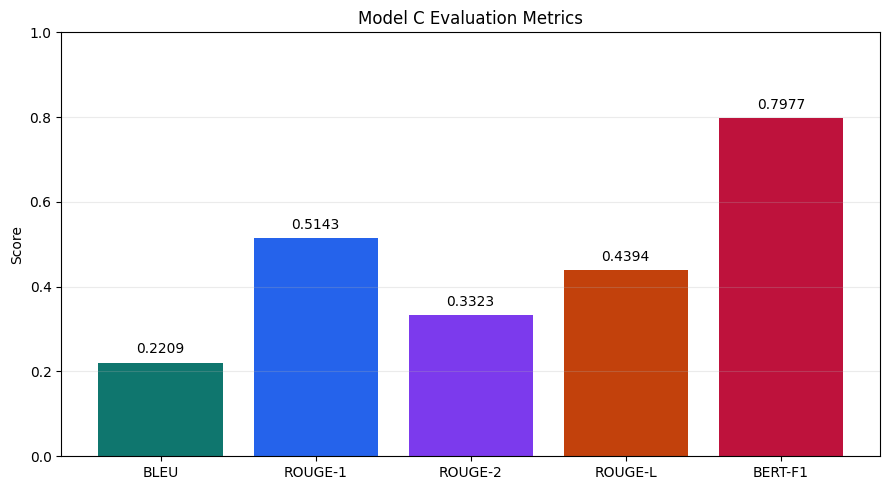

Saved metric plot to: /content/drive/MyDrive/models/model_C_metric_plot.png


In [12]:
metric_names = ['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERT-F1']
metric_values = [metrics_C[name] for name in metric_names]

plt.figure(figsize=(9, 5))
bars = plt.bar(metric_names, metric_values, color=['#0f766e', '#2563eb', '#7c3aed', '#c2410c', '#be123c'])
plt.ylim(0, 1)
plt.title('Model C Evaluation Metrics')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.25)
for bar, value in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.015, f'{value:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
METRIC_PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(METRIC_PLOT_PATH, dpi=200, bbox_inches='tight')
plt.show()
print('Saved metric plot to:', METRIC_PLOT_PATH)


## 12. Xem một vài ví dụ dự đoán

In [13]:
for i, row in enumerate(rows[:5], start=1):
    print('\n' + '=' * 80)
    print(f'Sample {i}')
    print('Q   :', row['Q'])
    print('Gold:', row['gold'])
    print('Pred:', row['pred'])



Sample 1
Q   : Luật Trật tự, an toàn giao thông đường bộ 2024 do cơ quan nào ban hành?
Gold: Quốc hội.
Pred: Do Quốc hội ban hành; được cơ quan thẩm quyền giải thích, hướng dẫn thi hành.

Sample 2
Q   : Khi tham gia giao thông, người đi bộ phải đi ở đâu?
Gold: Phải đi trên vỉa hè, lề đường; trường hợp đường không có vỉa hè, lề đường, người đi bộ phải đi sát mép đường.
Pred: Phải đi trên phần đường dành cho người đi Bộ.

Sample 3
Q   : Người điều khiển phương tiện tham gia giao thông phải mang theo những giấy tờ gì khi điều khiển xe ô tô?
Gold: Giấy phép lái xe phù hợp với loại xe đang điều khiển; chứng nhận đăng ký xe; chứng nhận kiểm định an toàn kỹ thuật và bảo vệ môi trường; chứng nhận bảo hiểm bắt buộc trách nhiệm dân sự của chủ xe cơ giới.
Pred: Chứng nhận đăng ký xe và chứng nhận kiểm định an toàn kỹ thuật và bảo vệ môi trường.

Sample 4
Q   : Phương tiện giao thông thông minh được hiểu như thế nào?
Gold: Là xe cơ giới cho phép tự động hóa một phần hoặc toàn bộ hoạt động điều kh

## 13. Demo hỏi thử

In [15]:
demo_questions = [
    'Người điều khiển xe mô tô cần mang theo giấy tờ gì?',
    'Luật Trật tự, an toàn giao thông đường bộ có hiệu lực từ ngày nào?',
    'Người đi xe máy có bắt buộc đội nón bảo hiểm không?',
]

for q in demo_questions:
    print('\nQ:', q)
    print('A:', generate_model_C(q))



Q: Người điều khiển xe mô tô cần mang theo giấy tờ gì?
A: Chứng nhận đăng ký xe và chứng nhận kiểm định an toàn kỹ thuật và bảo vệ môi trường.

Q: Luật Trật tự, an toàn giao thông đường bộ có hiệu lực từ ngày nào?
A: Ngày 01 tháng 01 năm 2025

Q: Người đi xe máy có bắt buộc đội nón bảo hiểm không?
A: Có, người lái xe mô tô, xe gắn máy và người ngồi trên đó phải đội nến bảo hiểm theo đúng quy chuẩn kỹ thuật quốc gia.
